# NB1 — Lab Data Loader, Plateau Extraction & Fault Injection
## SVF Framework — Lab Engine CSV Data (10 Hz, 29 Sensors)

**Key differences from N-CMAPSS pipeline:**
- Input: CSV files (one per run), already MinMax-scaled [0,1]
- 10 Hz sampling → `WINDOW_SIZE=100` (10 seconds), `STRIDE=10` (1 second)
- 29 sensors named A1..A29 (rename via `SENSOR_NAME_MAP` if needed)
- Steady-state detection via rolling-std on composite sensor signal (no altitude column)
- **7 classes only** — no SystemFault (all runs are nominal)
- No global scaler fitting — data is pre-scaled

**Outputs:**
- `processed_data/X_nominal.npy` — plateau windows for AE training
- `processed_data/sensor_cols.pkl` — sensor column names
- `processed_data/augmented_dataset.npz` — balanced 7-class fault dataset
- `plots/nb1_plateau_detection.png` — plateau detection diagnostic
- `plots/nb1_fault_visualisation.png` — fault injection examples


## 0 — Setup

In [1]:
import sys, os, gc, pickle, warnings, logging
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

sys.path.insert(0, '..')
from lab_data_utils import LabCSVLoader, collect_windows, LAB_FAULT_LABELS, LAB_FAULT_LABEL_TO_INT
from fault_engine   import FaultEngine

print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {"cuda" if torch.cuda.is_available() else "cpu"}')

2026-04-20 16:52:04,945 [INFO] NumExpr defaulting to 12 threads.


PyTorch  : 2.5.1+cu124
Device   : cuda


## 1 — Configuration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR  = '../data/lab'          # directory containing *.csv run files
PROC_DIR  = '../processed_data'
CKPT_DIR  = '../checkpoints'
PLOT_DIR  = '../plots'

for d in [PROC_DIR, CKPT_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)
    # print(f"created folder: {d}")

# ── Window parameters ─────────────────────────────────────────────────────────
WINDOW_SIZE = 100    # samples = 10 seconds at 10 Hz
STRIDE      = 10     # samples = 1 second
N_SENSORS   = 29
N_FAULT_TYPES = 7    # No SystemFault for lab data

# ── Sensor name mapping (optional) ───────────────────────────────────────────
# If you know the physical names, map them here for better reports.
# Otherwise leave as empty dict — A1..A29 will be used.
# Example: SENSOR_NAME_MAP = {'A1': 'T2', 'A2': 'T3', 'A5': 'NH', ...}
SENSOR_NAME_MAP = {}   # fill in if you want physical names in plots

# ── Speed column for plateau detection (optional) ────────────────────────────
# If you know which column is the speed/RPM signal (forms the staircase),
# set it here for more precise plateau detection.
# e.g. SPEED_COL = 'A5'  if NH (high-speed shaft) is column A5
# Leave as None to use mean rolling-std across all sensors.
SPEED_COL = 'A1'

# ── Fault injection ───────────────────────────────────────────────────────────
FAULT_RATIO = 1.00   # inject on every nominal window (natural ceiling)
FAULT_SEED  = 42

label_names = LAB_FAULT_LABELS
print('Configuration set.')
print(f'  DATA_DIR : {DATA_DIR}')
print(f'  Classes  : {list(label_names.values())}')

Configuration set.
  DATA_DIR : ../data/lab
  Classes  : ['Nominal', 'Bias', 'Scaling', 'Drift', 'Intermittent', 'Compound', 'MultiSensor']


## 2 — Initialise loader & auto-calibrate plateau threshold

In [19]:
loader = LabCSVLoader(
    data_dir        = DATA_DIR,
    window_size     = WINDOW_SIZE,
    stride          = STRIDE,
    sensor_name_map = SENSOR_NAME_MAP,
    speed_col       = SPEED_COL,
    # std_threshold is auto-calibrated from data — override here if needed
    # std_threshold = 0.015,
    min_plateau_len = 0,   # minimum 20 seconds of steady state per segment
)

print(f'CSV files found        : {len(loader.csv_files)}')
for f in loader.csv_files:
    print(f'  {f.name}')
print(f'Auto-calibrated threshold: {loader.std_threshold}')
print(f'Sensor columns         : {loader.sensor_cols[:5]} ... ({len(loader.sensor_cols)} total)')

2026-04-20 15:38:29,717 [INFO] LabCSVLoader: found 10 file(s)
2026-04-20 15:38:29,824 [INFO] Auto-calibrated plateau threshold: 0.0001  (60th pct of rolling-std distribution)


CSV files found        : 10
  1590_Binary_Data_Dump_1.csv
  1591_Binary_Data_Dump_1.csv
  1595_Binary_Data_Dump_1.csv
  1596_Binary_Data_Dump_1.csv
  1600_Binary_Data_Dump_1.csv
  1607_Binary_Data_Dump_1.csv
  1610_Binary_Data_Dump_1.csv
  1613_Binary_Data_Dump_1.csv
  1673_Binary_Data_Dump_1.csv
  1681_Binary_Data_Dump_1.csv
Auto-calibrated threshold: 0.0001
Sensor columns         : ['A1', 'A2', 'A3', 'A4', 'A5'] ... (29 total)


### 2a — Plateau detection diagnostic

In [4]:
loader.std_threshold = loader.std_threshold * 3
# Print per-file plateau summary
summary = loader.plateau_summary()
print('Plateau detection summary:')
print(summary.to_string(index=False))
print(f'\nTotal nominal windows : {summary["n_windows"].sum():,}')

# If any file has very low plateau % (< 30%), the threshold may need adjustment.
# Try loader.std_threshold = loader.std_threshold * 1.5 and re-run.
low_plateau = summary[summary['plateau_pct'].str.rstrip('%').astype(float) < 30]
if len(low_plateau) > 0:
    print(f'\nWARNING: {len(low_plateau)} files have < 30% plateau.')
    print('Consider increasing std_threshold or decreasing min_plateau_len.')
    print(f'Suggested: loader.std_threshold = {loader.std_threshold * 1.5:.4f}')

2026-04-20 15:01:08,312 [INFO] Plateau detection: 15245 / 20002 rows (76.2%) | threshold=0.000
2026-04-20 15:01:08,477 [INFO] Plateau detection: 19022 / 25021 rows (76.0%) | threshold=0.000
2026-04-20 15:01:08,646 [INFO] Plateau detection: 19756 / 23274 rows (84.9%) | threshold=0.000
2026-04-20 15:01:08,744 [INFO] Plateau detection: 10793 / 14441 rows (74.7%) | threshold=0.000
2026-04-20 15:01:08,881 [INFO] Plateau detection: 19506 / 23203 rows (84.1%) | threshold=0.000
2026-04-20 15:01:09,040 [INFO] Plateau detection: 19805 / 24320 rows (81.4%) | threshold=0.000
2026-04-20 15:01:09,181 [INFO] Plateau detection: 15242 / 19957 rows (76.4%) | threshold=0.000
2026-04-20 15:01:09,307 [INFO] Plateau detection: 15565 / 20257 rows (76.8%) | threshold=0.000
2026-04-20 15:01:09,424 [INFO] Plateau detection: 13146 / 17921 rows (73.4%) | threshold=0.000
2026-04-20 15:01:09,533 [INFO] Plateau detection: 13080 / 18067 rows (72.4%) | threshold=0.000


Plateau detection summary:
                       file  total_rows  plateau_rows plateau_pct  n_windows
1590_Binary_Data_Dump_1.csv       20002         15245       76.2%       1515
1591_Binary_Data_Dump_1.csv       25021         19022       76.0%       1893
1595_Binary_Data_Dump_1.csv       23274         19756       84.9%       1966
1596_Binary_Data_Dump_1.csv       14441         10793       74.7%       1070
1600_Binary_Data_Dump_1.csv       23203         19506       84.1%       1941
1607_Binary_Data_Dump_1.csv       24320         19805       81.4%       1971
1610_Binary_Data_Dump_1.csv       19957         15242       76.4%       1515
1613_Binary_Data_Dump_1.csv       20257         15565       76.8%       1547
1673_Binary_Data_Dump_1.csv       17921         13146       73.4%       1305
1681_Binary_Data_Dump_1.csv       18067         13080       72.4%       1299

Total nominal windows : 16,022


### 2b — Visualise plateau detection on first file

2026-04-20 15:01:16,315 [INFO] Plateau detection: 15245 / 20002 rows (76.2%) | threshold=0.000
2026-04-20 15:01:16,344 [INFO] 1590_Binary_Data_Dump_1.csv: 15245 plateau rows -> 1991 windows


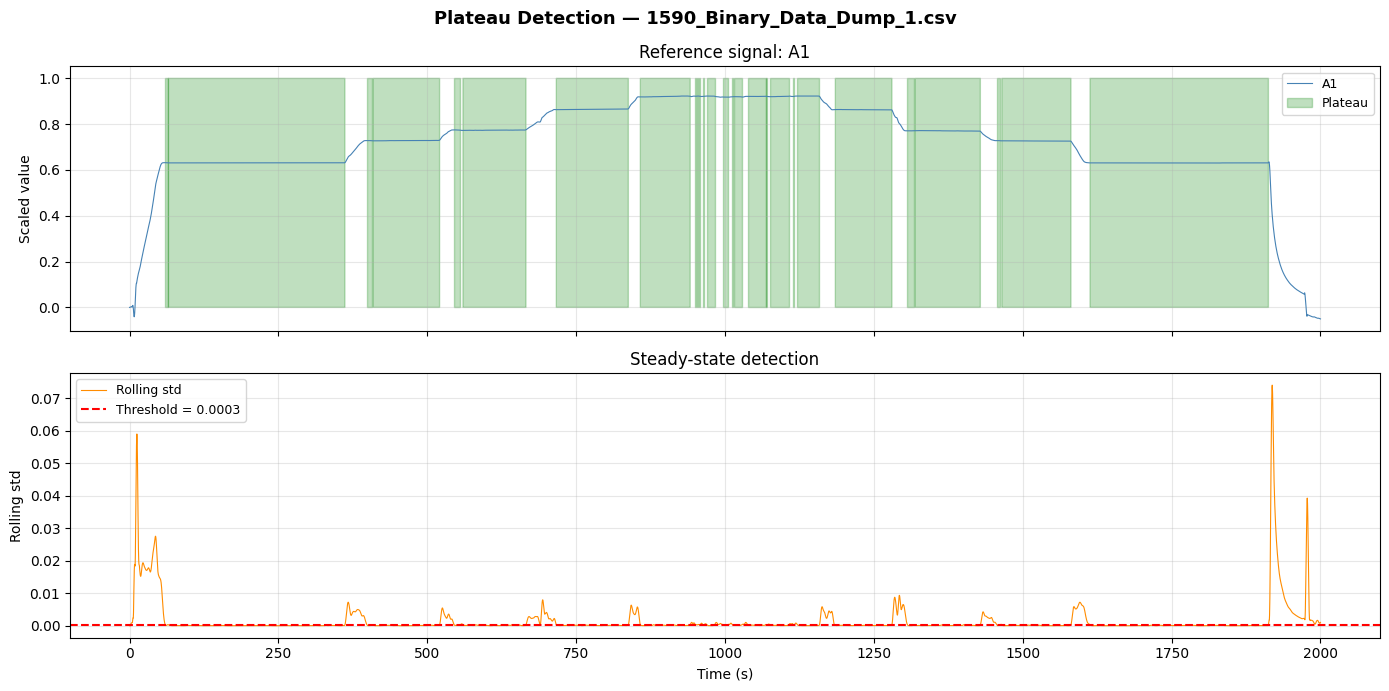

Plateau rows: 15,245 / 20,002 (76.2%)


In [5]:
# Show the first file with plateau regions highlighted
first_batch = next(loader.iter_files(plateau_only=False))
df_full     = first_batch['df']
plateau_mask= first_batch['plateau_mask']
sensor_cols = first_batch['sensor_cols']

# Use the first sensor column as representative signal
ref_col  = SPEED_COL if SPEED_COL else sensor_cols[0]
disp_name= SENSOR_NAME_MAP.get(ref_col, ref_col)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle(f'Plateau Detection — {first_batch["file"]}', fontsize=13, fontweight='bold')

t = np.arange(len(df_full)) / 10.0   # seconds
axes[0].plot(t, df_full[ref_col].values, lw=0.8, color='steelblue', label=disp_name)
axes[0].fill_between(t, 0, 1, where=plateau_mask, alpha=0.25, color='green', label='Plateau')
axes[0].set_ylabel('Scaled value')
axes[0].set_title(f'Reference signal: {disp_name}')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Rolling std
roll_std_vals = pd.Series(df_full[ref_col].values).rolling(50, min_periods=25).std().fillna(0).values
axes[1].plot(t, roll_std_vals, lw=0.8, color='darkorange', label='Rolling std')
axes[1].axhline(loader.std_threshold, color='red', ls='--', lw=1.5,
                label=f'Threshold = {loader.std_threshold:.4f}')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Rolling std')
axes[1].set_title('Steady-state detection')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb1_plateau_detection.png', dpi=130)
plt.show()
print(f'Plateau rows: {plateau_mask.sum():,} / {len(df_full):,} ({100*plateau_mask.mean():.1f}%)')

## 3 — Collect nominal plateau windows
Data is already MinMax-scaled — no scaler fitting needed.

In [6]:
print('Collecting plateau windows across all CSV files …')
X_nominal, sensor_cols = loader.collect_nominal_windows()

print(f'\nX_nominal shape   : {X_nominal.shape}  (N, T, S)')
print(f'Sensors           : {sensor_cols[:5]} ... ({len(sensor_cols)} total)')
print(f'Memory footprint  : {X_nominal.nbytes / 1e6:.1f} MB')
print(f'Value range       : {X_nominal.min():.4f} → {X_nominal.max():.4f}')

if X_nominal.shape[0] < 500:
    print(f'\nWARNING: Only {X_nominal.shape[0]} nominal windows.')
    print('Consider decreasing min_plateau_len or std_threshold.')
    print('AE may underfit with very few windows.')
else:
    print(f'\n✓ Sufficient nominal windows for AE training.')

2026-04-20 15:01:26,362 [INFO] Plateau detection: 15245 / 20002 rows (76.2%) | threshold=0.000
2026-04-20 15:01:26,401 [INFO] 1590_Binary_Data_Dump_1.csv: 15245 plateau rows -> 1515 windows


2026-04-20 15:01:26,624 [INFO] Plateau detection: 19022 / 25021 rows (76.0%) | threshold=0.000
2026-04-20 15:01:26,657 [INFO] 1591_Binary_Data_Dump_1.csv: 19022 plateau rows -> 1893 windows
2026-04-20 15:01:26,868 [INFO] Plateau detection: 19756 / 23274 rows (84.9%) | threshold=0.000
2026-04-20 15:01:26,894 [INFO] 1595_Binary_Data_Dump_1.csv: 19756 plateau rows -> 1966 windows
2026-04-20 15:01:27,057 [INFO] Plateau detection: 10793 / 14441 rows (74.7%) | threshold=0.000
2026-04-20 15:01:27,057 [INFO] 1596_Binary_Data_Dump_1.csv: 10793 plateau rows -> 1070 windows
2026-04-20 15:01:27,274 [INFO] Plateau detection: 19506 / 23203 rows (84.1%) | threshold=0.000
2026-04-20 15:01:27,300 [INFO] 1600_Binary_Data_Dump_1.csv: 19506 plateau rows -> 1941 windows
2026-04-20 15:01:27,512 [INFO] Plateau detection: 19805 / 24320 rows (81.4%) | threshold=0.000
2026-04-20 15:01:27,533 [INFO] 1607_Binary_Data_Dump_1.csv: 19805 plateau rows -> 1971 windows
2026-04-20 15:01:27,742 [INFO] Plateau detection: 


X_nominal shape   : (16022, 100, 29)  (N, T, S)
Sensors           : ['A1', 'A2', 'A3', 'A4', 'A5'] ... (29 total)
Memory footprint  : 185.9 MB
Value range       : 0.0000 → 1.0000

✓ Sufficient nominal windows for AE training.


## 4 — Save nominal windows

In [7]:
np.save(f'{PROC_DIR}/X_nominal.npy', X_nominal)
with open(f'{PROC_DIR}/sensor_cols.pkl', 'wb') as f:
    pickle.dump(sensor_cols, f)

# Save display names separately for reporting
display_names = loader.display_names(sensor_cols)
with open(f'{PROC_DIR}/sensor_display_names.pkl', 'wb') as f:
    pickle.dump(display_names, f)

print(f'Saved X_nominal         → {PROC_DIR}/X_nominal.npy')
print(f'Saved sensor_cols       → {PROC_DIR}/sensor_cols.pkl')
print(f'Saved display_names     → {PROC_DIR}/sensor_display_names.pkl')
print(f'Shape: {X_nominal.shape}')
print(f'Display names: {display_names[:5]} ...')

Saved X_nominal         → ../processed_data/X_nominal.npy
Saved sensor_cols       → ../processed_data/sensor_cols.pkl
Saved display_names     → ../processed_data/sensor_display_names.pkl
Shape: (16022, 100, 29)
Display names: ['A1', 'A2', 'A3', 'A4', 'A5'] ...


## 5 — Visualise sensor distributions across plateau steps
The staircase means different plateaus have different sensor levels.
This is expected — all are nominal.

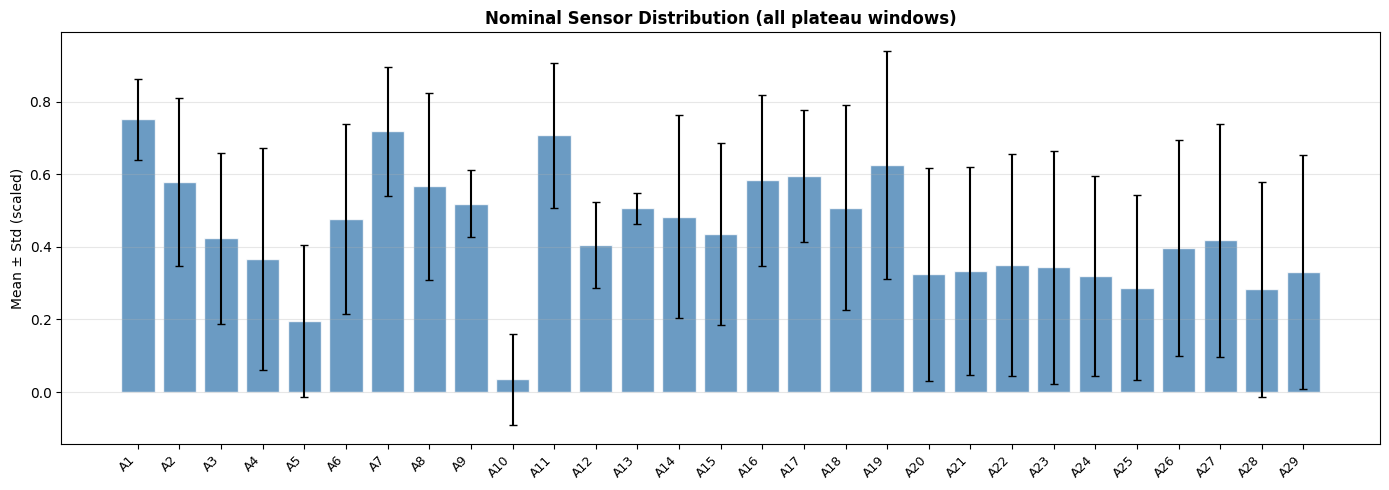

In [8]:
# Show mean ± std per sensor across all nominal windows
means = X_nominal.mean(axis=(0, 1))   # (S,)
stds  = X_nominal.std(axis=(0, 1))    # (S,)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(sensor_cols))
ax.bar(x, means, yerr=stds, capsize=3, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(display_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean ± Std (scaled)')
ax.set_title('Nominal Sensor Distribution (all plateau windows)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb1_sensor_distribution.png', dpi=120)
plt.show()

## 6 — Fault Injection (Cases 1–3 only, 7 classes)
SystemFault (Case 4) is excluded — all lab runs are nominal.

Sensor ID labels are captured from the actual injected sensor, not random.

In [4]:
engine = FaultEngine(seed=FAULT_SEED)
print(engine.summary())
print(f'\nN_SENSORS for injection: {len(sensor_cols)}')

2026-04-20 16:53:31,968 [INFO] FaultEngine initialized (seed=42, fs=1 Hz) | mag_range=[1.00, 3.00] | interm_range=[1.00, 3.00]


FaultEngine – Supported Fault Cases  [Multi-Dataset Version]
Case 1 (Single Sensor, Single Fault):
  • Bias          – additive constant offset  (mag = 20–60% of range)
  • Scaling       – multiplicative gain error (mag = 20–60%)
  • Drift         – linearly increasing ramp  (mag = 20–60% of range)
  • Intermittent  – random pulse spikes       (mag = 0.5–2.0 × std, prob=0.25)

Case 2 (Single Sensor, Multi-Fault):
  • Compound      – sequential fault composition

Case 3 (Multi-Sensor Faults):
  • MultiSensor   – independent faults on ≥2 channels

Case 4 (System Fault):
  • SystemFault   – N-CMAPSS physical degradation (hs, RUL)

NOTE: Magnitudes significantly increased vs. original single-dataset
      version to ensure clear detectability after MinMaxScaling.

N_SENSORS for injection: 29


### 6a — Visualise fault types on a sample window

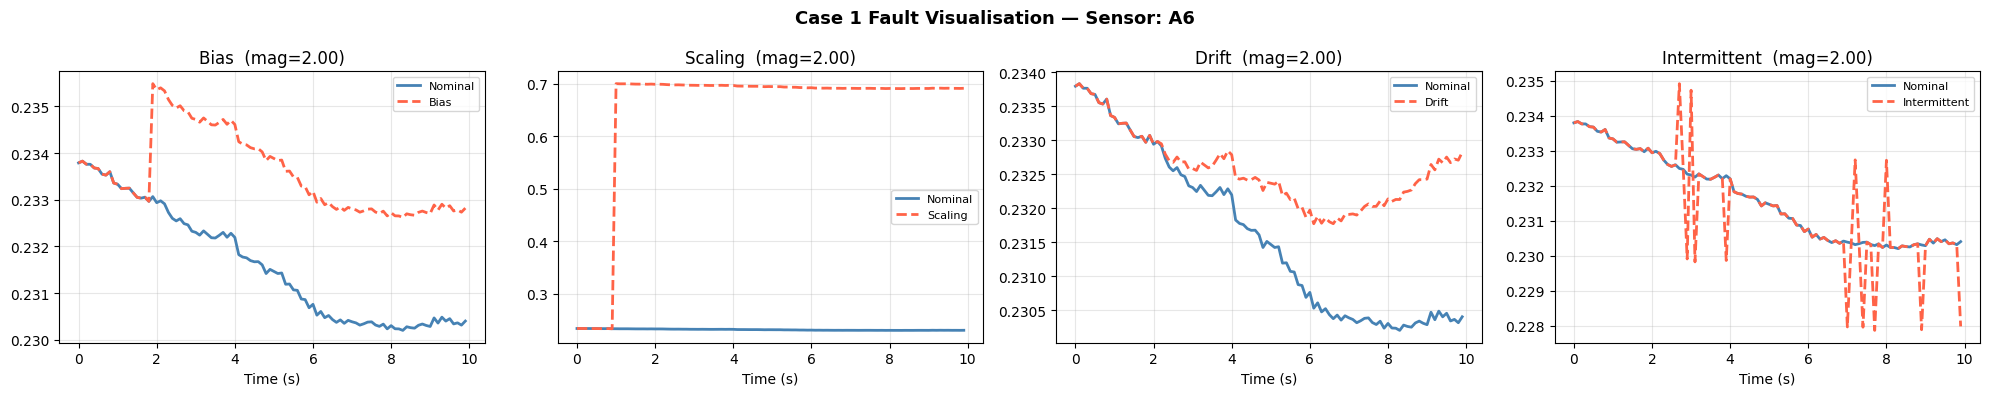

In [10]:
sample_win  = X_nominal[0].copy()    # (T, S)
fault_types = ['bias', 'scaling', 'drift', 'intermittent']
SENSOR_DEMO = 5   # A1 (first sensor)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle(f'Case 1 Fault Visualisation — Sensor: {display_names[SENSOR_DEMO]}',
             fontsize=13, fontweight='bold')

for ax, ft in zip(axes, fault_types):
    win_f, si, lbl, _, mag = engine.inject_single_sensor_single_fault(
        sample_win, fault_type=ft, sensor_idx=SENSOR_DEMO, magnitude=2.0
    )
    t_ = np.arange(WINDOW_SIZE) / 10.0
    ax.plot(t_, sample_win[:, SENSOR_DEMO], label='Nominal', lw=2, color='steelblue')
    ax.plot(t_, win_f[:, SENSOR_DEMO], label=ft.capitalize(), lw=2, ls='--', color='tomato')
    ax.set_title(f'{ft.capitalize()}  (mag={mag:.2f})')
    ax.set_xlabel('Time (s)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb1_fault_visualisation.png', dpi=120)
plt.show()

## 7 — Build Balanced Augmented Dataset

In [5]:
# ── Inject Cases 1–3 with real sensor_idx labels ─────────────────────────────
from fault_engine import FAULT_LABEL_TO_INT

X_all    = [X_nominal]
y_fault  = [np.zeros(len(X_nominal), dtype=np.int64)]
y_sensor = [np.zeros(len(X_nominal), dtype=np.int64)]
y_mag    = [np.zeros(len(X_nominal), dtype=np.float32)]

rng_inj = np.random.default_rng(FAULT_SEED)
fault_types_cycle = ['bias', 'scaling', 'drift', 'intermittent']

# ── Case 1 - inject 4 rounds (on per fault type) to match case 2/3 size ────────

for round_idx, ft in enumerate (fault_types_cycle):
    print(f'Injecting case 1 - {ft}(round {round_idx + 1}/4)... ')
    engine_r = FaultEngine(seed = FAULT_SEED + round_idx)
    N = len(X_nominal)
    rng_shuffle = np.random.default_rng(FAULT_SEED + round_idx + 100)

    indices = rng_shuffle.permutation(len(X_nominal))
    
    X_case  = X_nominal.copy()
    yf_case = np.zeros(N, dtype=np.int64)
    ys_case = np.zeros(N, dtype=np.int64)
    ym_case = np.zeros(N, dtype=np.float32)
    
    for i in indices:
        win = X_nominal[i].copy()
        win_f, s_idx, lbl, _, mag = engine.inject_single_sensor_single_fault(win, fault_type=ft)
        X_case[i]  = win_f
        yf_case[i] = lbl
        ys_case[i] = int(s_idx)
        ym_case[i] = float(mag)
        
    X_all.append(X_case)
    y_fault.append(yf_case)
    y_sensor.append(ys_case)
    y_mag.append(ym_case)
    
    print(f'    {ft}: {N:,} windows injected')

for case in [2, 3]:
    print(f'  Injecting Case {case} faults …')
    N        = len(X_nominal)
    n_faulty = int(N * FAULT_RATIO)
    indices  = rng_inj.choice(N, size=n_faulty, replace=False)

    X_case  = X_nominal.copy()
    yf_case = np.zeros(N, dtype=np.int64)
    ys_case = np.zeros(N, dtype=np.int64)
    ym_case = np.zeros(N, dtype=np.float32)

    for i in indices:
        win = X_case[i]
        if case == 1:
            win_f, s_idx, lbl, _, mag = engine.inject_single_sensor_single_fault(win)
            X_case[i]  = win_f
            yf_case[i] = lbl
            ys_case[i] = int(s_idx)
            ym_case[i] = float(mag)
        elif case == 2:
            win_f, s_idx, lbl, seq = engine.inject_compound_fault(win)
            X_case[i]  = win_f
            yf_case[i] = lbl
            ys_case[i] = int(s_idx)
            ym_case[i] = float(np.mean([s[1] for s in seq]))
        elif case == 3:
            win_f, specs = engine.inject_multi_sensor_faults(win)
            X_case[i]  = win_f
            yf_case[i] = FAULT_LABEL_TO_INT['MultiSensor']
            ys_case[i] = int(specs[0].sensor_idx)
            ym_case[i] = float(specs[0].magnitude)

    # faulty_mask = yf_case > 0
    X_all.append(X_case)
    y_fault.append(yf_case)
    y_sensor.append(ys_case)
    y_mag.append(ym_case)
    print(f'    Case {case}: {N:,} windows injected')

X_dataset = np.concatenate(X_all,    axis=0)
y_fault   = np.concatenate(y_fault).astype(np.int64)
y_sensor  = np.concatenate(y_sensor).astype(np.int64)
y_mag     = np.concatenate(y_mag).astype(np.float32)

print(f'\nDataset shape (before balancing): {X_dataset.shape}')
print('Class distribution:')
for l, c in zip(*np.unique(y_fault, return_counts=True)):
    print(f'  {label_names.get(l, str(l)):15s}: {c:>8,}')

2026-04-20 16:53:39,801 [INFO] FaultEngine initialized (seed=42, fs=1 Hz) | mag_range=[1.00, 3.00] | interm_range=[1.00, 3.00]


Injecting case 1 - bias(round 1/4)... 


2026-04-20 16:53:40,446 [INFO] FaultEngine initialized (seed=43, fs=1 Hz) | mag_range=[1.00, 3.00] | interm_range=[1.00, 3.00]


    bias: 16,022 windows injected
Injecting case 1 - scaling(round 2/4)... 


2026-04-20 16:53:40,780 [INFO] FaultEngine initialized (seed=44, fs=1 Hz) | mag_range=[1.00, 3.00] | interm_range=[1.00, 3.00]


    scaling: 16,022 windows injected
Injecting case 1 - drift(round 3/4)... 


2026-04-20 16:53:41,338 [INFO] FaultEngine initialized (seed=45, fs=1 Hz) | mag_range=[1.00, 3.00] | interm_range=[1.00, 3.00]


    drift: 16,022 windows injected
Injecting case 1 - intermittent(round 4/4)... 
    intermittent: 16,022 windows injected
  Injecting Case 2 faults …
    Case 2: 16,022 windows injected
  Injecting Case 3 faults …
    Case 3: 16,022 windows injected

Dataset shape (before balancing): (112154, 100, 29)
Class distribution:
  Nominal        :   16,022
  Bias           :   16,022
  Scaling        :   16,022
  Drift          :   16,022
  Intermittent   :   16,022
  Compound       :   16,022
  MultiSensor    :   16,022


### 7a — Balance classes

In [6]:
rng_bal = np.random.default_rng(FAULT_SEED+1)
keep_idx = np.arange(len(y_fault))
rng_bal.shuffle(keep_idx)

X_dataset = X_dataset[keep_idx]
y_fault = y_fault[keep_idx]
y_sensor = y_sensor[keep_idx]
y_mag = y_mag[keep_idx]

print(f'Dataset shape (balanced, 7 Cases): {X_dataset.shape}')
print('Final class distribution: ')
for l, c in zip(*np.unique(y_fault, return_counts=True)):
    print(f'  {label_names.get(l, str(l)):15s}: {c:>8,}')

Dataset shape (balanced, 7 Cases): (112154, 100, 29)
Final class distribution: 
  Nominal        :   16,022
  Bias           :   16,022
  Scaling        :   16,022
  Drift          :   16,022
  Intermittent   :   16,022
  Compound       :   16,022
  MultiSensor    :   16,022


In [7]:
print(X_dataset.min(), X_dataset.max())

0.0 1.0


In [8]:
for cls in np.unique(y_fault):
    X_cls = X_dataset[y_fault == cls]
    print(f"Class {cls}: mean={X_cls.mean():.4f}, max={X_cls.max():.4f}, std={X_cls.std():.4f}")

Class 0: mean=0.4435, max=1.0000, std=0.2952
Class 1: mean=0.4313, max=1.0000, std=0.2971
Class 2: mean=0.4530, max=1.0000, std=0.3016
Class 3: mean=0.4438, max=1.0000, std=0.2953
Class 4: mean=0.4435, max=1.0000, std=0.2952
Class 5: mean=0.4411, max=1.0000, std=0.2982
Class 6: mean=0.4417, max=1.0000, std=0.2993


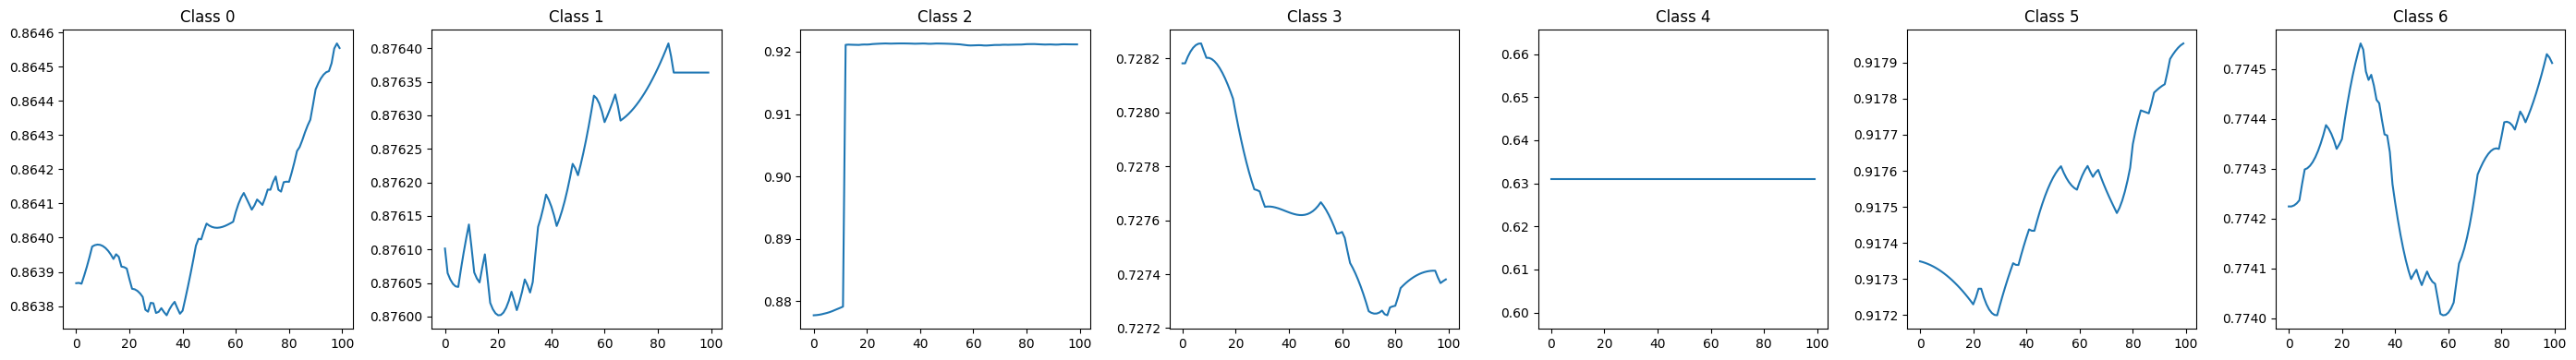

In [9]:
fig, axes = plt.subplots(1, 7, figsize=(28, 4))
for cls in np.unique(y_fault):
    X_cls = X_dataset[y_fault == cls]
    axes[cls].plot(X_cls[0, :, 0])   # first window, sensor A1
    axes[cls].set_title(f'Class {cls}')
plt.tight_layout(); plt.show()


## 8 — Save augmented dataset

In [10]:
np.savez_compressed(
    f'{PROC_DIR}/augmented_dataset.npz',
    X   = X_dataset,
    y_f = y_fault,
    y_s = y_sensor,
    y_m = y_mag,
)

# Save metadata
import json
meta = {
    'n_sensors'      : len(sensor_cols),
    'window_size'    : WINDOW_SIZE,
    'stride'         : STRIDE,
    'sampling_rate'  : 10,
    'n_fault_types'  : N_FAULT_TYPES,
    # 'target_per_class': TARGET_PER_CLASS,
    'fault_labels'   : label_names,
    'sensor_cols'    : sensor_cols,
    'display_names'  : display_names,
    # 'n_csv_files'    : len(loader.csv_files),
    # 'plateau_threshold': loader.std_threshold,
}
with open(f'{CKPT_DIR}/lab_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved augmented_dataset.npz  → {PROC_DIR}/')
print(f'  X      : {X_dataset.shape}  ({X_dataset.nbytes/1e9:.2f} GB)')
print(f'  y_fault: {y_fault.shape}')
print(f'Saved lab_meta.json          → {CKPT_DIR}/')
print('\n✓ NB1 complete — Proceed to NB2_Autoencoder.ipynb')

Saved augmented_dataset.npz  → ../processed_data/
  X      : (112154, 100, 29)  (1.30 GB)
  y_fault: (112154,)
Saved lab_meta.json          → ../checkpoints/

✓ NB1 complete — Proceed to NB2_Autoencoder.ipynb


---
## ↻ Reload Block

In [3]:
import sys, os, pickle, json, warnings
import numpy as np
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
from lab_data_utils_with_PELT import LabCSVLoader, LAB_FAULT_LABELS
from fault_engine import FaultEngine

PROC_DIR = '../processed_data'; CKPT_DIR = '../checkpoints'; PLOT_DIR = '../plots'
with open(f'{CKPT_DIR}/lab_meta.json') as f: meta = json.load(f)

label_names   = LAB_FAULT_LABELS
WINDOW_SIZE   = meta['window_size']
N_FAULT_TYPES = meta['n_fault_types']
sensor_cols   = meta['sensor_cols']
display_names = meta['display_names']

with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f: sensor_cols = pickle.load(f)
X_nominal = np.load(f'{PROC_DIR}/X_nominal.npy')
_d = np.load(f'{PROC_DIR}/augmented_dataset.npz')
X_dataset = _d['X']; y_fault = _d['y_f']; y_sensor = _d['y_s']; y_mag = _d['y_m']

print(f'✓ Reloaded: X_nominal={X_nominal.shape}  X_dataset={X_dataset.shape}')
print(f'  Classes: {list(label_names.values())}')

✓ Reloaded: X_nominal=(16022, 100, 29)  X_dataset=(112154, 100, 29)
  Classes: ['Nominal', 'Bias', 'Scaling', 'Drift', 'Intermittent', 'Compound', 'MultiSensor']
